# Credit Card Fraud Detection

This project builds a model to detect fraudulent credit card transactions using the Kaggle credit card dataset. The dataset is highly imbalanced (only a small fraction of transactions are fraud), so this is also a good project to practice handling imbalanced data.

# Import Libraries

In [119]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    classification_report,
    confusion_matrix,
)

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

from xgboost import XGBClassifier

import joblib

sns.set_style("darkgrid")

RANDOM_STATE = 42

In [120]:
# Creating folders to save graphs, models and result files
os.makedirs("Graphs", exist_ok=True)
os.makedirs("Models", exist_ok=True)
os.makedirs("Result", exist_ok=True)

# Load Dataset

In [121]:
# loading the dataset
df = pd.read_csv("creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [122]:
# checking shape of dataset
df.shape

(284807, 31)

In [123]:
# checking column info and data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

# Data Cleaning

In [124]:
# checking missing values
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [125]:
# checking duplicate rows
df.duplicated().sum()

np.int64(1081)

In [126]:
# removing duplicate rows
df = df.drop_duplicates()
df.shape

(283726, 31)

# Exploratory Data Analysis

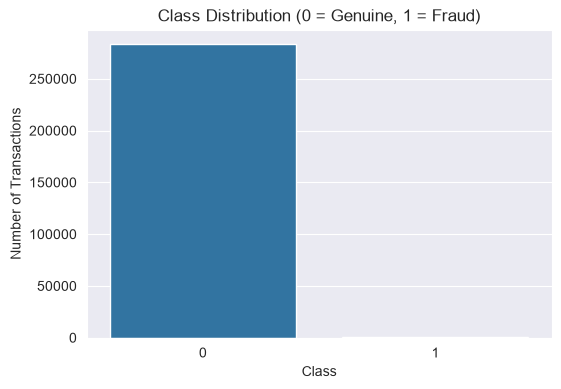

In [127]:
# class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x="Class", data=df)
plt.title("Class Distribution (0 = Genuine, 1 = Fraud)")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")
plt.savefig("Graphs/class_distribution.png", dpi=300)
plt.show()

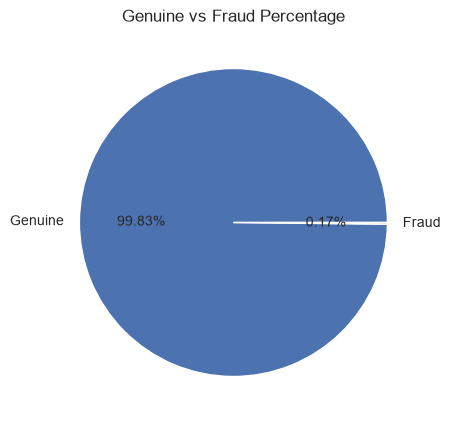

In [128]:
# fraud percentage pie chart
class_counts = df["Class"].value_counts()

plt.figure(figsize=(5, 5))
plt.pie(class_counts, labels=["Genuine", "Fraud"], autopct="%1.2f%%",
        colors=["#4C72B0", "#C44E52"])
plt.title("Genuine vs Fraud Percentage")
plt.savefig("graphs/fraud_pie_chart.png", dpi=300)
plt.show()

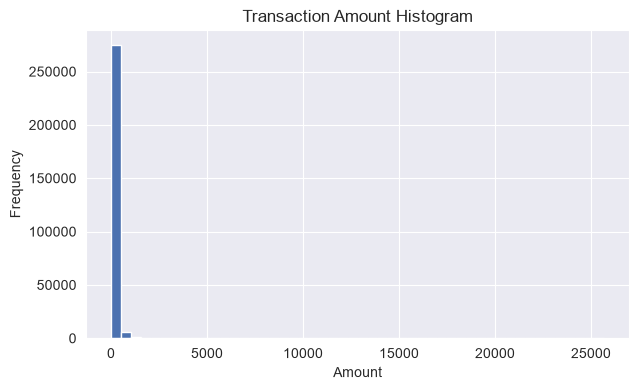

In [129]:
# amount histogram
plt.figure(figsize=(7, 4))
plt.hist(df["Amount"], bins=50, color="#4C72B0")
plt.title("Transaction Amount Histogram")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

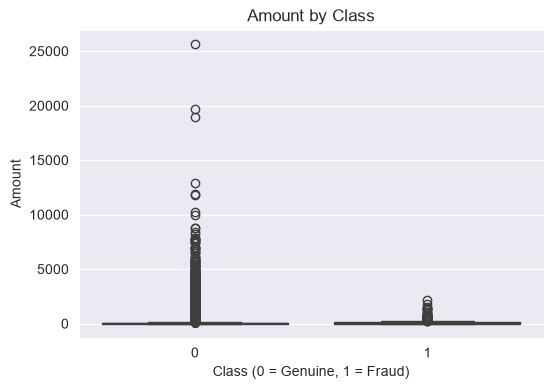

In [130]:
# amount boxplot, genuine vs fraud
plt.figure(figsize=(6, 4))
sns.boxplot(x="Class", y="Amount", data=df)
plt.title("Amount by Class")
plt.xlabel("Class (0 = Genuine, 1 = Fraud)")
plt.show()

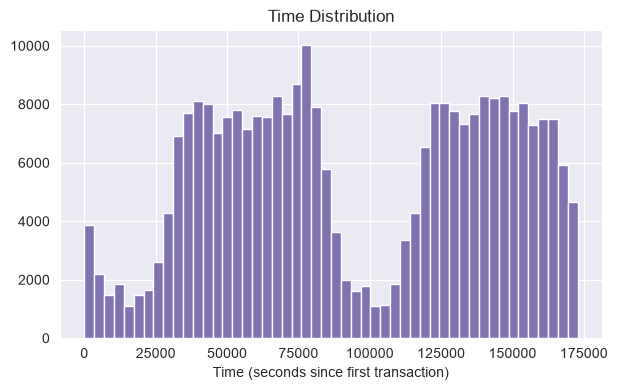

In [131]:
# time distribution
plt.figure(figsize=(7, 4))
plt.hist(df["Time"], bins=50, color="#8172B2")
plt.title("Time Distribution")
plt.xlabel("Time (seconds since first transaction)")
plt.show()

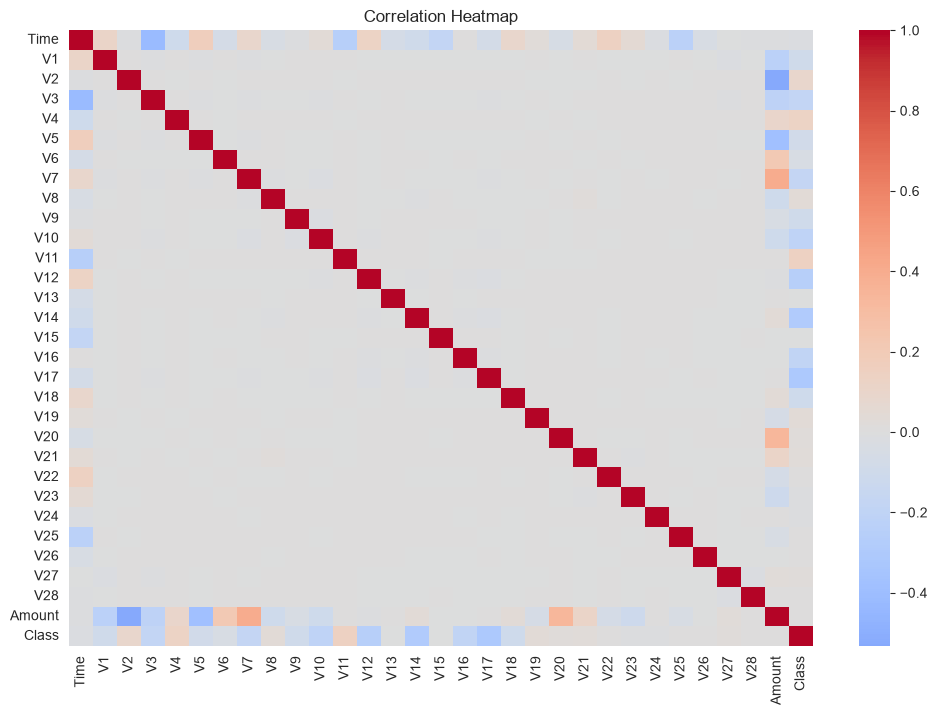

In [132]:
# correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.savefig("Graphs/correlation_heatmap.png", dpi=300)
plt.show()

# Feature Scaling

In [133]:
# scaling Amount and Time columns since their range is very different from the rest
scaler = StandardScaler()
df["Amount"] = scaler.fit_transform(df[["Amount"]])
df["Time"] = scaler.fit_transform(df[["Time"]])
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.996823,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.244200,0
1,-1.996823,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.342584,0
2,-1.996802,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.158900,0
3,-1.996802,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.139886,0
4,-1.996781,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.073813,0


# Train Test Split

In [134]:
X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

X_train.shape, X_test.shape

((226980, 30), (56746, 30))

# Handling Class Imbalance

In [135]:
# class counts before balancing
y_train.value_counts()

Class
0    226602
1       378
Name: count, dtype: int64

In [136]:
# balancing training data with SMOTE
smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
y_train_sm.value_counts()

Class
0    226602
1    226602
Name: count, dtype: int64

In [137]:
# also trying random undersampling, just to compare class counts
rus = RandomUnderSampler(random_state=RANDOM_STATE)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)
y_train_rus.value_counts()

Class
0    378
1    378
Name: count, dtype: int64

SMOTE gives more training samples to learn from than undersampling (which throws away a lot of genuine transactions), so the models below are trained on the SMOTE data.

# Model Training

### Logistic Regression

In [138]:
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_sm, y_train_sm)

y_pred_lr = log_reg.predict(X_test)
y_proba_lr = log_reg.predict_proba(X_test)[:, 1]

### Random Forest

In [139]:
rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train_sm, y_train_sm)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

### XGBoost

In [140]:
xgb = XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.1,
    eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1
)
xgb.fit(X_train_sm, y_train_sm)

y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

# Model Evaluation

### Logistic Regression Results

In [141]:
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

Accuracy : 0.9737250202657456
Precision: 0.05313700384122919
Recall   : 0.8736842105263158
F1 Score : 0.10018105009052504

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746



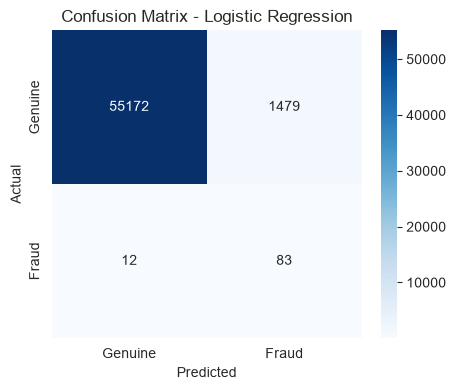

In [142]:
# confusion matrix - logistic regression
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Genuine", "Fraud"], yticklabels=["Genuine", "Fraud"])
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("Graphs/confusion_matrix_lr.png", dpi=300)
plt.show()

### Random Forest Results

In [143]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Accuracy : 0.9994889507630493
Precision: 0.9230769230769231
Recall   : 0.7578947368421053
F1 Score : 0.8323699421965318

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.92      0.76      0.83        95

    accuracy                           1.00     56746
   macro avg       0.96      0.88      0.92     56746
weighted avg       1.00      1.00      1.00     56746



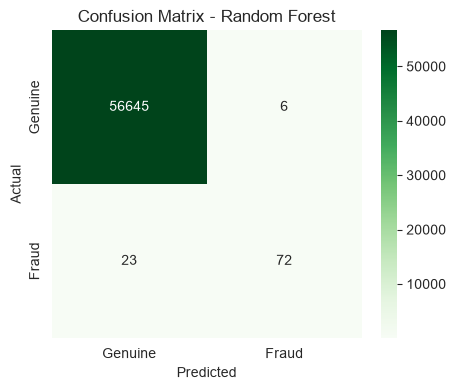

In [144]:
# confusion matrix - random forest
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Genuine", "Fraud"], yticklabels=["Genuine", "Fraud"])
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("Graphs/confusion_matrix_rf.png", dpi=300)
plt.show()

### XGBoost Results

In [145]:
print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))

Accuracy : 0.9990836358509851
Precision: 0.6972477064220184
Recall   : 0.8
F1 Score : 0.7450980392156863

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.70      0.80      0.75        95

    accuracy                           1.00     56746
   macro avg       0.85      0.90      0.87     56746
weighted avg       1.00      1.00      1.00     56746



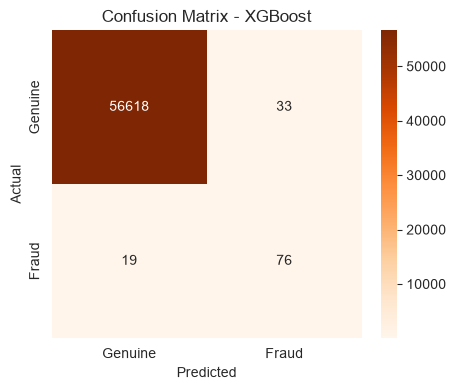

In [146]:
# confusion matrix - xgboost
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Oranges",
            xticklabels=["Genuine", "Fraud"], yticklabels=["Genuine", "Fraud"])
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("Graphs/confusion_matrix_xgb.png", dpi=300)
plt.show()

### ROC Curve

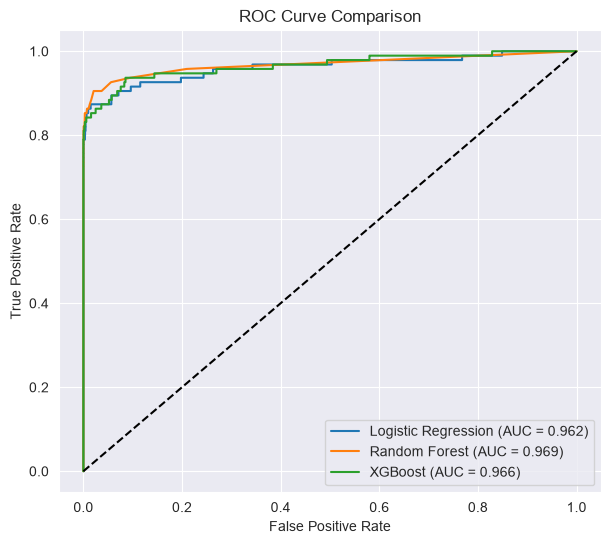

In [147]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)

plt.figure(figsize=(7, 6))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_proba_lr):.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_score(y_test, y_proba_rf):.3f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {roc_auc_score(y_test, y_proba_xgb):.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.savefig("Graphs/roc_curve.png", dpi=300)
plt.show()

# Feature Importance

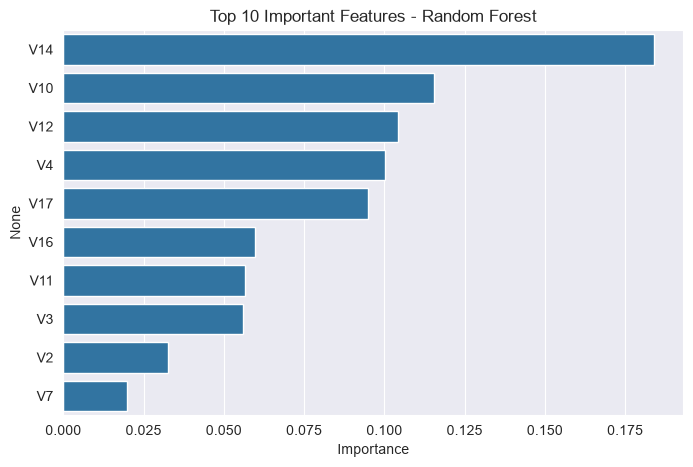

In [148]:
# feature importance from random forest
importance = pd.Series(rf.feature_importances_, index=X.columns)
top10 = importance.sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
sns.barplot(x=top10.values, y=top10.index)
plt.title("Top 10 Important Features - Random Forest")
plt.xlabel("Importance")
plt.savefig("Graphs/feature_importance.png", dpi=300)
plt.show()

# Model Comparison

In [149]:
results = [
    {"Model": "Logistic Regression", "Accuracy": accuracy_score(y_test, y_pred_lr),
     "Precision": precision_score(y_test, y_pred_lr), "Recall": recall_score(y_test, y_pred_lr),
     "F1": f1_score(y_test, y_pred_lr), "ROC AUC": roc_auc_score(y_test, y_proba_lr)},

    {"Model": "Random Forest", "Accuracy": accuracy_score(y_test, y_pred_rf),
     "Precision": precision_score(y_test, y_pred_rf), "Recall": recall_score(y_test, y_pred_rf),
     "F1": f1_score(y_test, y_pred_rf), "ROC AUC": roc_auc_score(y_test, y_proba_rf)},

    {"Model": "XGBoost", "Accuracy": accuracy_score(y_test, y_pred_xgb),
     "Precision": precision_score(y_test, y_pred_xgb), "Recall": recall_score(y_test, y_pred_xgb),
     "F1": f1_score(y_test, y_pred_xgb), "ROC AUC": roc_auc_score(y_test, y_proba_xgb)},
]

comparison_df = pd.DataFrame(results).sort_values("ROC AUC", ascending=False).reset_index(drop=True)
comparison_df.to_csv("Result/model_comparison.csv", index=False)
comparison_df.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC AUC
0,Random Forest,0.9995,0.9231,0.7579,0.8324,0.9687
1,XGBoost,0.9991,0.6972,0.8000,0.7451,0.9662
2,Logistic Regression,0.9737,0.0531,0.8737,0.1002,0.9619


# Saving the Best Model

In [153]:
best_model_name = comparison_df.iloc[0]["Model"]
print("Best model based on ROC-AUC:", best_model_name)

# picking the actual trained model object based on the name
if best_model_name == "Logistic Regression":
    best_model = log_reg
elif best_model_name == "Random Forest":
    best_model = rf
else:
    best_model = xgb

joblib.dump(best_model, "Models/best_model.pkl")
joblib.dump(scaler, "Models/scaler.pkl")

print("Best model and scaler saved inside Models/ folder.")

Best model based on ROC-AUC: Random Forest
Best model and scaler saved inside Models/ folder.


# Conclusion

All three models were trained on the SMOTE-balanced data and tested on the same untouched test set. Based on the comparison table above, the model with the highest ROC-AUC score was chosen as the best model and saved for future use. Since the dataset is so imbalanced, precision, recall and F1 score for the fraud class matter more here than plain accuracy. As a next step, hyperparameter tuning (like GridSearchCV) could be tried to push the scores even higher.